# Week12 Final Evaluation and Spatial Visualization

本 Notebook 对应第十二周任务：计算最终 MAE/RMSE，绘制预测曲线，并复现论文中类似 Fig.7 / Fig.8 的空间关系可视化。

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'week12' else _cwd
sys.path.insert(0, os.path.join(_root, 'week11'))
sys.path.insert(0, os.path.join(_root, 'week12'))

# Clear same-name modules that may have been imported from previous weeks.
for _module_name in ['data', 'models', 'train', 'visualization']:
    if _module_name in sys.modules:
        del sys.modules[_module_name]

from data import prepare_st_data
from models import IndependentLSTM, GCNLSTMRegressor, MultiScaleGCNLSTMRegressor
from train import SingleScaleGraphDataset, MultiScaleGraphDataset, train_model, evaluate_model
from visualization import (
    summarize_histories,
    plot_training_curves,
    plot_station_prediction,
    plot_matrix,
    compute_spatial_influence_matrix,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Torch version: {torch.__version__}')
print(f'Device: {device}')

Torch version: 2.6.0+cu124
Device: cuda


## 1. 数据与参数

In [2]:
FEATURE_COLUMNS = [
    'power',
    'nwp_globalirrad',
    'nwp_directirrad',
    'nwp_temperature',
    'nwp_humidity',
    'nwp_windspeed',
]
SEQ_LEN_15MIN = 16
SEQ_LEN_1H = 4
PRED_HORIZON = 1
DIST_THRESHOLD_KM = 150.0
BATCH_SIZE = 16
EPOCHS = 5
LR = 1e-3
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

prepared = prepare_st_data(
    feature_columns=FEATURE_COLUMNS,
    distance_threshold_km=DIST_THRESHOLD_KM,
    seq_len_15min=SEQ_LEN_15MIN,
    seq_len_1h=SEQ_LEN_1H,
    pred_horizon=PRED_HORIZON,
)

edge_index = torch.from_numpy(prepared.edge_index).long().to(device)
input_dim = prepared.train_x_15min.shape[-1]
print(f'Train samples: {len(prepared.train_y)}')
print(f'Test samples: {len(prepared.test_y)}')
print(f'Stations: {prepared.station_ids}')

Train samples: 6515
Test samples: 1629
Stations: ['station00', 'station01', 'station02', 'station03', 'station04', 'station05', 'station06', 'station07', 'station08', 'station09']


In [3]:
train_single_ds = SingleScaleGraphDataset(prepared.train_x_15min, prepared.train_y)
test_single_ds = SingleScaleGraphDataset(prepared.test_x_15min, prepared.test_y)
train_multi_ds = MultiScaleGraphDataset(prepared.train_x_15min, prepared.train_x_1h, prepared.train_y)
test_multi_ds = MultiScaleGraphDataset(prepared.test_x_15min, prepared.test_x_1h, prepared.test_y)

train_single_loader = DataLoader(train_single_ds, batch_size=BATCH_SIZE, shuffle=True)
test_single_loader = DataLoader(test_single_ds, batch_size=BATCH_SIZE, shuffle=False)
train_multi_loader = DataLoader(train_multi_ds, batch_size=BATCH_SIZE, shuffle=True)
test_multi_loader = DataLoader(test_multi_ds, batch_size=BATCH_SIZE, shuffle=False)

## 2. 训练最终对比模型

In [4]:
models_to_train = {}
histories = {}

baseline_model = IndependentLSTM(input_dim=input_dim, hidden_dim=32, output_dim=1, dropout=0.1).to(device)
baseline_model, histories['Independent LSTM'] = train_model(
    baseline_model, train_single_loader, test_single_loader, edge_index, EPOCHS, LR, device
)
models_to_train['Independent LSTM'] = baseline_model

gcn_lstm_model = GCNLSTMRegressor(input_dim=input_dim, gcn_hidden_dim=32, lstm_hidden_dim=32, output_dim=1, dropout=0.1).to(device)
gcn_lstm_model, histories['GCN-LSTM'] = train_model(
    gcn_lstm_model, train_single_loader, test_single_loader, edge_index, EPOCHS, LR, device
)
models_to_train['GCN-LSTM'] = gcn_lstm_model

multi_scale_model = MultiScaleGCNLSTMRegressor(input_dim=input_dim, gcn_hidden_dim=32, lstm_hidden_dim=32, output_dim=1, dropout=0.1).to(device)
multi_scale_model, histories['Multi-scale GCN-LSTM'] = train_model(
    multi_scale_model, train_multi_loader, test_multi_loader, edge_index, EPOCHS, LR, device
)
models_to_train['Multi-scale GCN-LSTM'] = multi_scale_model

Epoch 01/5 | train_loss=28.68219 | test_loss=16.78449 | test_mae=1.99051 | test_rmse=4.09689
Epoch 02/5 | train_loss=11.85578 | test_loss=8.45908 | test_mae=1.36801 | test_rmse=2.90845
Epoch 03/5 | train_loss=5.70848 | test_loss=4.20292 | test_mae=0.82357 | test_rmse=2.05010
Epoch 04/5 | train_loss=3.68249 | test_loss=3.21412 | test_mae=0.74706 | test_rmse=1.79280
Epoch 05/5 | train_loss=2.87166 | test_loss=2.81080 | test_mae=0.70184 | test_rmse=1.67655
Epoch 01/5 | train_loss=27.33421 | test_loss=18.99784 | test_mae=2.14818 | test_rmse=4.35865
Epoch 02/5 | train_loss=15.13236 | test_loss=13.53607 | test_mae=1.81550 | test_rmse=3.67914
Epoch 03/5 | train_loss=12.55252 | test_loss=11.67404 | test_mae=1.69246 | test_rmse=3.41673
Epoch 04/5 | train_loss=11.63738 | test_loss=10.99251 | test_mae=1.59889 | test_rmse=3.31550
Epoch 05/5 | train_loss=11.13312 | test_loss=11.47795 | test_mae=1.64896 | test_rmse=3.38791
Epoch 01/5 | train_loss=21.30183 | test_loss=12.91183 | test_mae=1.85883 | te

## 3. 最终 MAE / RMSE

,model,best_test_mae,best_test_rmse,best_test_loss
0,Independent LSTM,0.701843,1.676545,2.810805
1,Multi-scale GCN-LSTM,1.577483,3.238776,10.489669
2,GCN-LSTM,1.598894,3.315496,10.992513


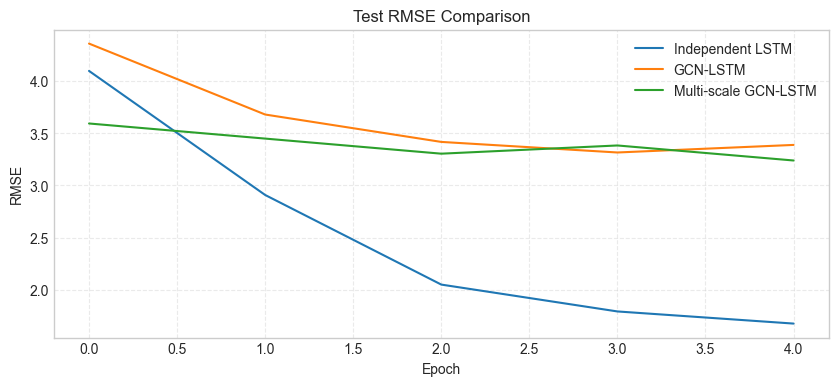

In [5]:
results_df = pd.DataFrame(summarize_histories(histories))
display(results_df)
plot_training_curves(histories)

## 4. 预测曲线可视化

Multi-scale GCN-LSTM | MAE=1.57748 | RMSE=3.23878


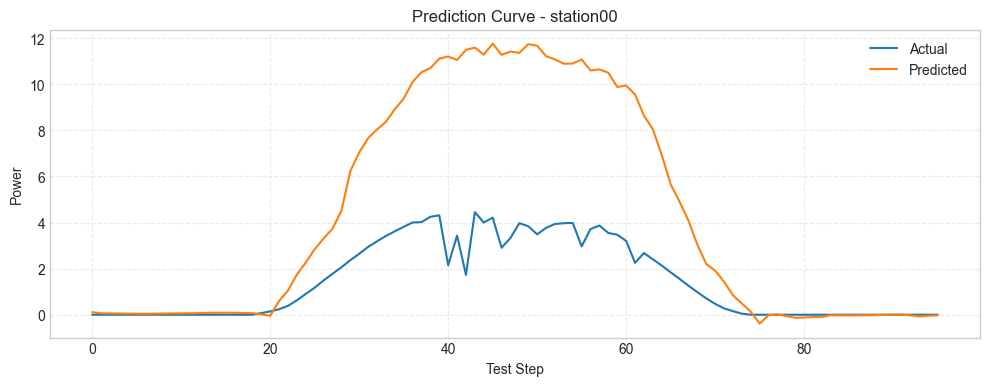

In [6]:
criterion = torch.nn.MSELoss()
_, mae, rmse, preds, targets = evaluate_model(
    multi_scale_model,
    test_multi_loader,
    edge_index,
    criterion,
    device,
    return_predictions=True,
)
print(f'Multi-scale GCN-LSTM | MAE={mae:.5f} | RMSE={rmse:.5f}')

plot_station_prediction(
    preds=preds,
    targets=targets,
    station_ids=prepared.station_ids,
    station_index=0,
    steps=96,
)

## 5. 空间关系与模型影响可视化

`A_dist` 是物理距离图，`A_corr` 是功率相关性图。梯度式空间影响矩阵用于近似观察模型输出对不同源站点输入的敏感程度，可作为无显式注意力模型的解释性替代。

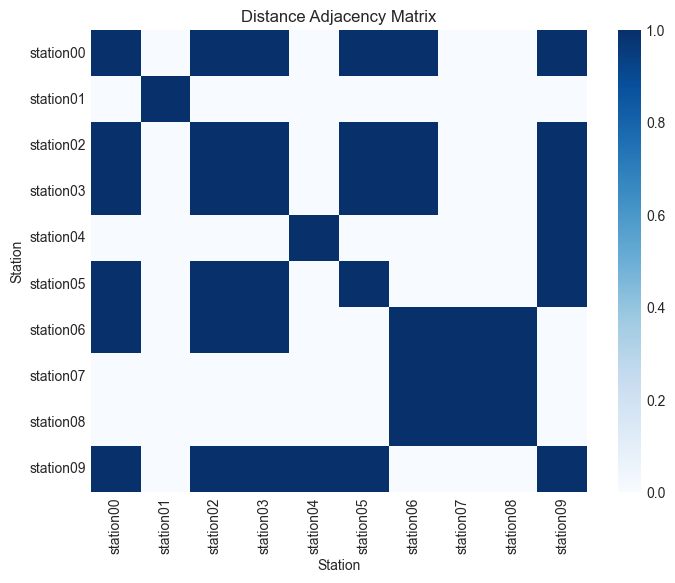

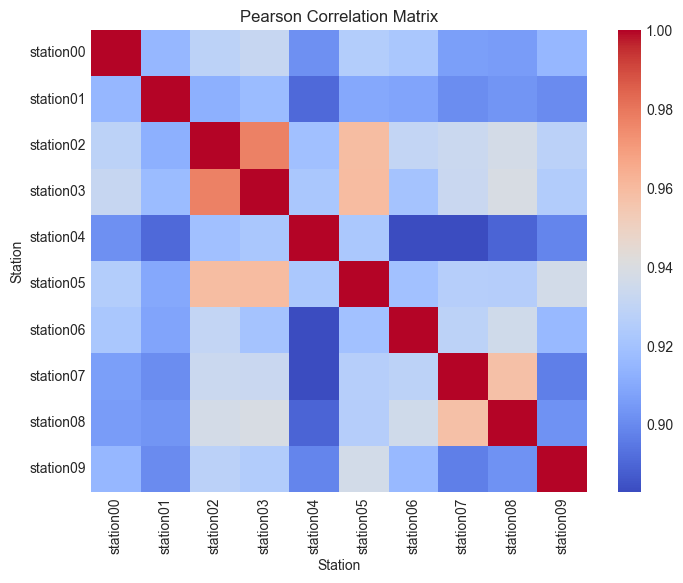

RuntimeError: cudnn RNN backward can only be called in training mode

In [7]:
plot_matrix(prepared.adjacency, prepared.station_ids, 'Distance Adjacency Matrix', cmap='Blues')
plot_matrix(prepared.correlation, prepared.station_ids, 'Pearson Correlation Matrix', cmap='coolwarm')

x_sample = prepared.test_x_15min[:1]
influence_matrix = compute_spatial_influence_matrix(
    model=gcn_lstm_model,
    x_sample=x_sample,
    edge_index=edge_index,
    device=device,
)
plot_matrix(influence_matrix, prepared.station_ids, 'Gradient-based Spatial Influence Matrix', cmap='magma')

## 6. 第十二周检查点说明

本周输出包括测试集 MAE/RMSE、预测曲线、距离邻接矩阵、Pearson 相关矩阵和模型空间影响矩阵。前三个指标用于说明预测精度，后三个图用于解释多站点之间的空间关系和模型利用空间信息的方式。